# Superstore Sales Analysis :

### Load the libraries :

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Load the Dataset :

In [2]:
df = pd.read_csv(r"C:\Users\Soumen Paul\Downloads\Sample - Superstore.csv",encoding="latin1")

### Understand the Dataset :

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [5]:
df.shape

(9994, 21)

In [6]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   row_id            9994 non-null   int64         
 1   order_id          9994 non-null   object        
 2   order_date        9994 non-null   datetime64[ns]
 3   ship_date         9994 non-null   datetime64[ns]
 4   ship_mode         9994 non-null   object        
 5   customer_id       9994 non-null   object        
 6   customer_name     9994 non-null   object        
 7   segment           9994 non-null   object        
 8   country           9994 non-null   object        
 9   city              9994 non-null   object        
 10  state             9994 non-null   object        
 11  postal_code       9994 non-null   int64         
 12  region            9994 non-null   object        
 13  product_id        9994 non-null   object        
 14  category          9994 n

## Data cleaning :

### Check the Null values :

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### Check the Duplicate Values :

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### Rename the columns :

In [10]:
df = df.rename(columns={'Row ID' : 'row_id',
                  'Order ID' : 'order_id',
                   'Order Date' : 'order_date',
                   'Ship Date' : 'ship_date',
                   'Ship Mode' : 'ship_mode',
                   'Customer ID' : 'customer_id',
                   'Customer Name' : 'customer_name',
                   'Segment' : 'segment',
                   'Country' : 'country',
                   'City' : 'city',
                   'State' : 'state',
                    'Postal Code' : 'postal_code',
                   'Region' : 'region',
                   'Product ID' : 'product_id',
                   'Category' : 'category',
                   'Sub-Category' : 'sub_category',
                   'Product Name' : 'product_name',
                   'Sales' : 'sales',
                   'Quantity' : 'quantity',
                   'Discount' : 'discount',
                    'Profit' : 'profit'})
                   
                   

### Convert dates to datetime format :

In [12]:
df['order_date'].dtype

dtype('O')

In [13]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [14]:
df['order_date']

0      2016-11-08
1      2016-11-08
2      2016-06-12
3      2015-10-11
4      2015-10-11
          ...    
9989   2014-01-21
9990   2017-02-26
9991   2017-02-26
9992   2017-02-26
9993   2017-05-04
Name: order_date, Length: 9994, dtype: datetime64[ns]

In [110]:
df['ship_date'] = pd.to_datetime(df['ship_date'])

## Perform feature engineering :

### Create order month column :

In [16]:
df['order_month'] = df['order_date'].dt.month

In [17]:
df['order_month']

0       11
1       11
2        6
3       10
4       10
        ..
9989     1
9990     2
9991     2
9992     2
9993     5
Name: order_month, Length: 9994, dtype: int32

In [18]:
df['order_month_name'] = df['order_date'].dt.month_name()

In [19]:
df['order_month_name']

0       November
1       November
2           June
3        October
4        October
          ...   
9989     January
9990    February
9991    February
9992    February
9993         May
Name: order_month_name, Length: 9994, dtype: object

### Create order year column :

In [20]:
df['order_year'] = df['order_date'].dt.year

In [21]:
df['order_year']

0       2016
1       2016
2       2016
3       2015
4       2015
        ... 
9989    2014
9990    2017
9991    2017
9992    2017
9993    2017
Name: order_year, Length: 9994, dtype: int32

### Create profit margin column :

In [23]:
df['profit_margin'] = (df['profit']/df['sales'])*100

In [24]:
df['profit_margin']

0       16.00
1       30.00
2       47.00
3      -40.00
4       11.25
        ...  
9989    16.25
9990    17.00
9991     7.50
9992    45.00
9993    30.00
Name: profit_margin, Length: 9994, dtype: float64

In [25]:
df[['sales', 'profit', 'profit_margin']].head()

,sales,profit,profit_margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


### Business KPI Analysis :

In [26]:
total_sales = df['sales'].sum()

In [27]:
print(total_sales)

2297200.8603000003


In [28]:
total_profit = df['profit'].sum()

In [29]:
print(total_profit)

286397.0217


In [30]:
total_orders = df['order_id'].count()

In [31]:
print(total_orders)

9994


In [32]:
average_order_value = total_sales / total_orders

In [33]:
print(average_order_value)

229.85800083049833


In [34]:
average_discount = df['discount'].mean()

In [35]:
print(average_discount)

0.15620272163297977


In [36]:
profit_margin = (total_profit/total_sales)*100

In [37]:
print(profit_margin)

12.467217240315604


### Analyse product performance.

In [38]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,order_month,order_month_name,order_year,profit_margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,November,2016,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,November,2016,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,June,2016,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,October,2015,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,October,2015,11.25


In [39]:
top_10_products_by_sales = df.groupby('product_name',as_index=False)['sales'].sum().sort_values(by='sales',ascending=False).head(10)

In [40]:
print(top_10_products_by_sales)

                                          product_name      sales
404              Canon imageCLASS 2200 Advanced Copier  61599.824
650  Fellowes PB500 Electric Punch Plastic Comb Bin...  27453.384
444  Cisco TelePresence System EX90 Videoconferenci...  22638.480
786       HON 5400 Series Task Chairs for Big and Tall  21870.576
686         GBC DocuBind TL300 Electric Binding System  19823.479
688   GBC Ibimaster 500 Manual ProClick Binding System  19024.500
805               Hewlett Packard LaserJet 3310 Copier  18839.686
787  HP Designjet T520 Inkjet Large Format Printer ...  18374.895
683          GBC DocuBind P400 Electric Binding System  17965.068
813        High Speed Automatic Electric Letter Opener  17030.312


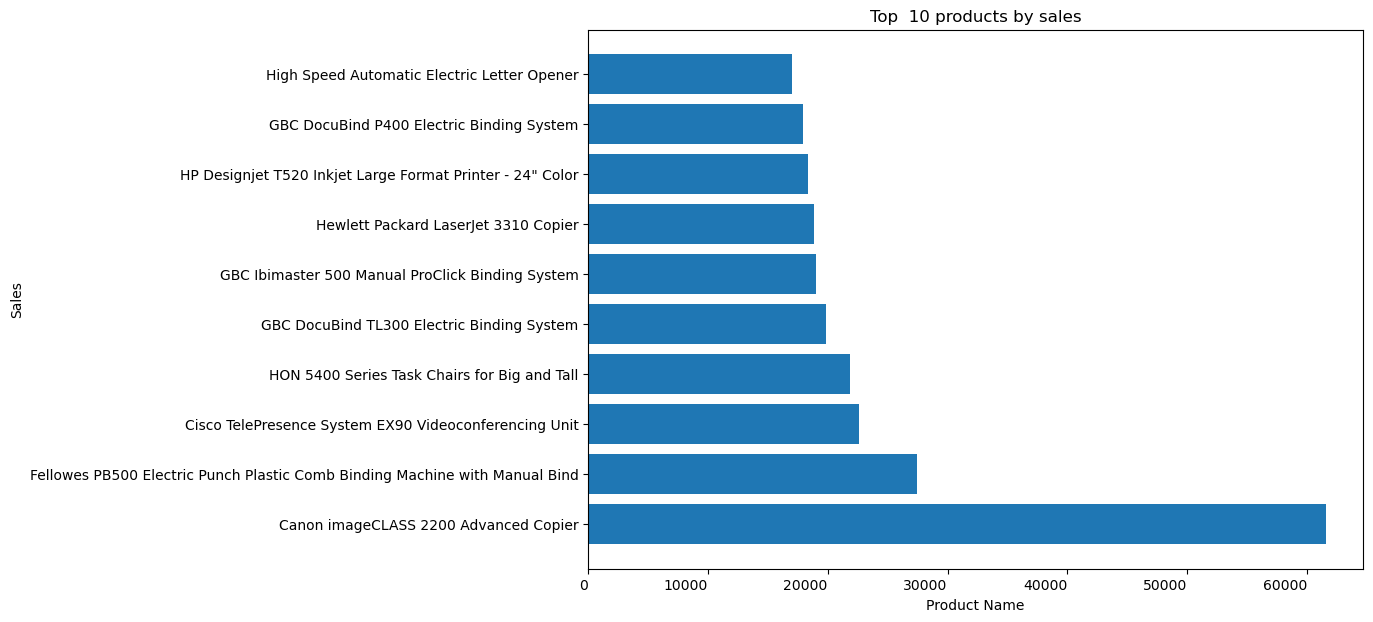

In [41]:
plt.figure(figsize=(10,7))
plt.barh(
    top_10_products_by_sales['product_name'],
    top_10_products_by_sales['sales']
)
plt.title('Top  10 products by sales')
plt.xlabel('Product Name')
plt.ylabel('Sales')
plt.xticks(ha='right')
plt.show()

In [42]:
top_10_products_by_profit = df.groupby('product_name',as_index=False)['profit'].sum().sort_values(by='profit',ascending=False).head(10)

In [43]:
print(top_10_products_by_profit)

                                           product_name      profit
404               Canon imageCLASS 2200 Advanced Copier  25199.9280
650   Fellowes PB500 Electric Punch Plastic Comb Bin...   7753.0390
805                Hewlett Packard LaserJet 3310 Copier   6983.8836
400                  Canon PC1060 Personal Laser Copier   4570.9347
787   HP Designjet T520 Inkjet Large Format Printer ...   4094.9766
165                   Ativa V4110MDD Micro-Cut Shredder   3772.9461
19     3D Systems Cube Printer, 2nd Generation, Magenta   3717.9714
1276  Plantronics Savi W720 Multi-Device Wireless He...   3696.2820
895                Ibico EPK-21 Electric Binding System   3345.2823
1840                  Zebra ZM400 Thermal Label Printer   3343.5360


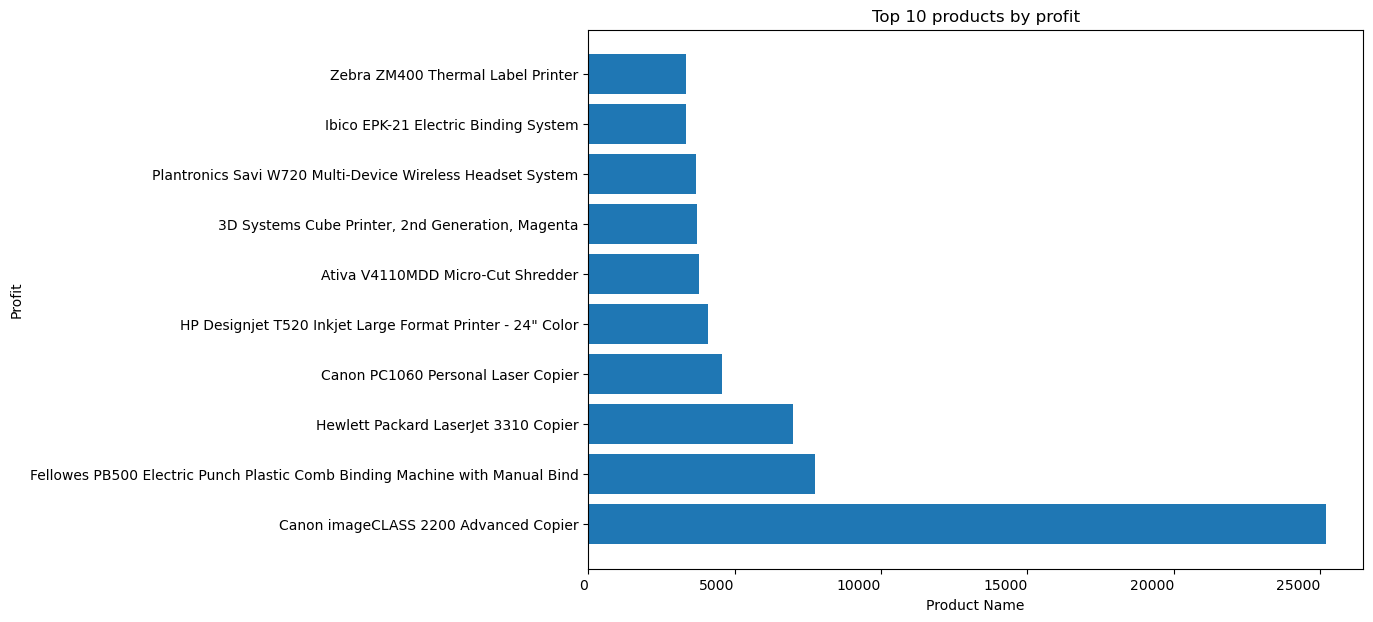

In [44]:
plt.figure(figsize=(10,7))
plt.barh(
    top_10_products_by_profit['product_name'],
    top_10_products_by_profit['profit']
)
plt.title('Top 10 products by profit')
plt.xlabel('Product Name')
plt.ylabel('Profit')
plt.xticks(ha='right')
plt.show()

In [45]:
bottom_10_products_by_profit = df.groupby('product_name',as_index=False)['profit'].sum().sort_values(by='profit',ascending=True).head(10)

In [46]:
print(bottom_10_products_by_profit)

                                           product_name     profit
475           Cubify CubeX 3D Printer Double Head Print -8879.9704
985           Lexmark MX611dhe Monochrome Laser Printer -4589.9730
476           Cubify CubeX 3D Printer Triple Head Print -3839.9904
425   Chromcraft Bull-Nose Wood Oval Conference Tabl... -2876.1156
376   Bush Advantage Collection Racetrack Conference... -1934.3976
683           GBC DocuBind P400 Electric Binding System -1878.1662
444   Cisco TelePresence System EX90 Videoconferenci... -1811.0784
1043  Martin Yale Chadless Opener Electric Letter Op... -1299.1836
285                        Balt Solid Wood Round Tables -1201.0581
364   BoxOffice By Design Rectangular and Half-Moon ... -1148.4375


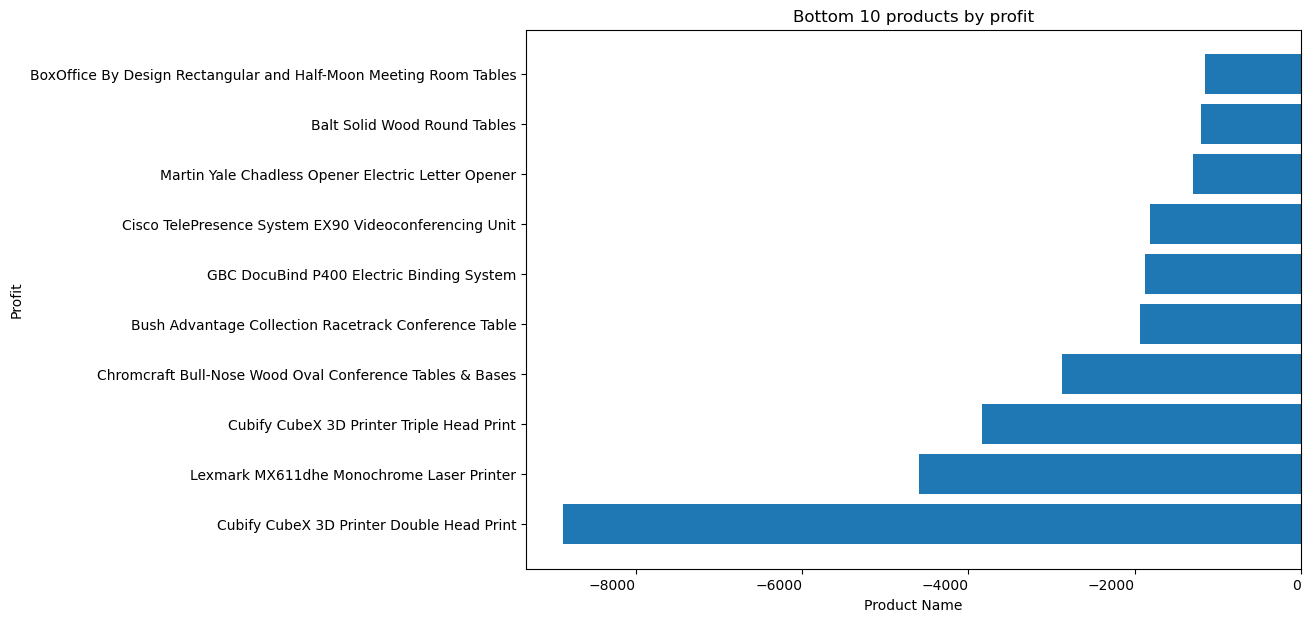

In [47]:
plt.figure(figsize=(10,7))
plt.barh(
    bottom_10_products_by_profit['product_name'],
    bottom_10_products_by_profit['profit']
)
plt.title('Bottom 10 products by profit')
plt.xlabel('Product Name')
plt.ylabel('Profit')
plt.xticks(ha='right')
plt.show()

### Analyse category and sub-category performance.

In [48]:
sales_by_category = df.groupby('category',as_index=False)['sales'].sum().sort_values(by='sales',ascending=False)

In [49]:
print(sales_by_category)

          category        sales
2       Technology  836154.0330
0        Furniture  741999.7953
1  Office Supplies  719047.0320


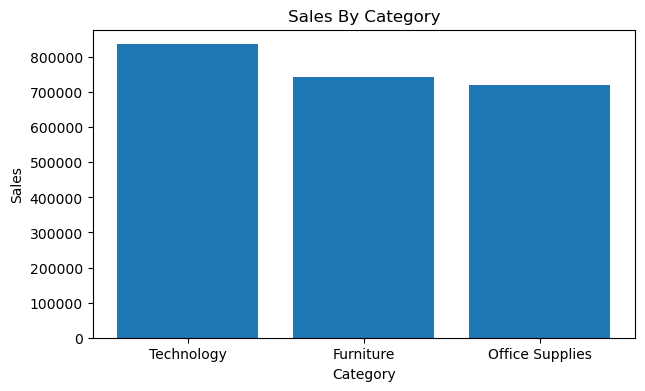

In [50]:
plt.figure(figsize=(7,4))
plt.bar(sales_by_category['category'],
        sales_by_category['sales']
       )
plt.title('Sales By Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()


In [51]:
profit_by_category = df.groupby('category',as_index=False)['profit'].sum().sort_values(by='profit',ascending=False)

In [52]:
print(profit_by_category)

          category       profit
2       Technology  145454.9481
1  Office Supplies  122490.8008
0        Furniture   18451.2728


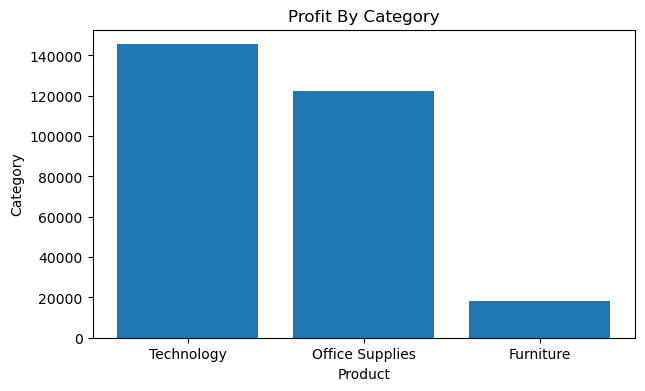

In [53]:
plt.figure(figsize=(7,4))
plt.bar(
    profit_by_category['category'],
    profit_by_category['profit']
)
plt.title ('Profit By Category')
plt.xlabel('Product')
plt.ylabel('Category')
plt.show()

In [54]:
sales_by_sub_category = df.groupby('sub_category',as_index=False)['sales'].sum().sort_values(by='sales',ascending=False)

In [55]:
print(sales_by_sub_category)

   sub_category        sales
13       Phones  330007.0540
5        Chairs  328449.1030
14      Storage  223843.6080
16       Tables  206965.5320
3       Binders  203412.7330
11     Machines  189238.6310
0   Accessories  167380.3180
6       Copiers  149528.0300
4     Bookcases  114879.9963
1    Appliances  107532.1610
9   Furnishings   91705.1640
12        Paper   78479.2060
15     Supplies   46673.5380
2           Art   27118.7920
7     Envelopes   16476.4020
10       Labels   12486.3120
8     Fasteners    3024.2800


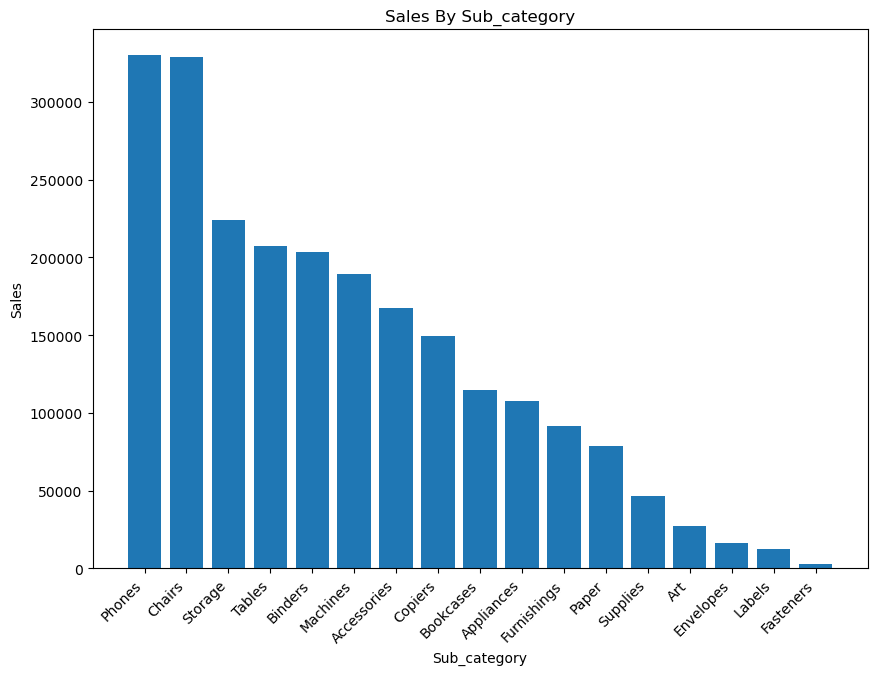

In [56]:
plt.figure(figsize=(10,7))
plt.bar(
    sales_by_sub_category['sub_category'],
    sales_by_sub_category['sales']
)
plt.title('Sales By Sub_category')
plt.xlabel('Sub_category')
plt.ylabel('Sales')
plt.xticks(rotation=45,ha='right')
plt.show()

In [57]:
profit_by_sub_category = df.groupby('sub_category',as_index=False)['profit'].sum().sort_values(by='profit',ascending=False)

In [58]:
print(profit_by_sub_category)

   sub_category      profit
6       Copiers  55617.8249
13       Phones  44515.7306
0   Accessories  41936.6357
12        Paper  34053.5693
3       Binders  30221.7633
5        Chairs  26590.1663
14      Storage  21278.8264
1    Appliances  18138.0054
9   Furnishings  13059.1436
7     Envelopes   6964.1767
2           Art   6527.7870
10       Labels   5546.2540
11     Machines   3384.7569
8     Fasteners    949.5182
15     Supplies  -1189.0995
4     Bookcases  -3472.5560
16       Tables -17725.4811


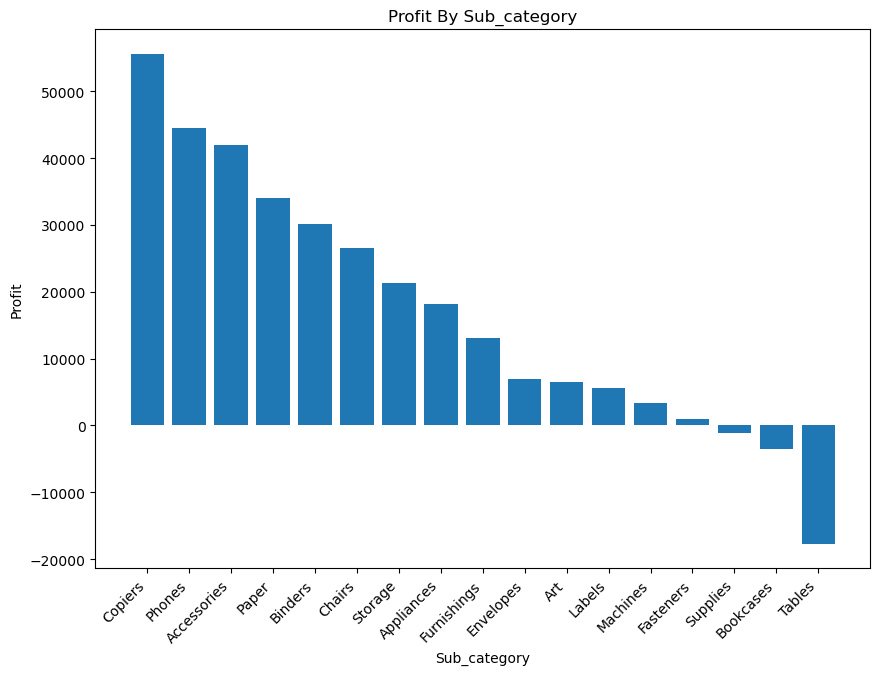

In [59]:
plt.figure(figsize=(10,7))
plt.bar(
    profit_by_sub_category['sub_category'],
    profit_by_sub_category['profit']
)
plt.title('Profit By Sub_category')
plt.xlabel('Sub_category')
plt.ylabel('Profit')
plt.xticks(rotation=45,ha='right')
plt.show()


### Analyse customer performance.

In [60]:
top_10_customers_by_sales = df.groupby('customer_name',as_index=False)['sales'].sum().sort_values(by='sales',ascending=False).head(10)

In [61]:
print(top_10_customers_by_sales)

          customer_name      sales
686         Sean Miller  25043.050
730        Tamara Chand  19052.218
622        Raymond Buch  15117.339
757        Tom Ashbrook  14595.620
6         Adrian Barton  14473.571
441        Ken Lonsdale  14175.229
671        Sanjit Chand  14142.334
334        Hunter Lopez  12873.298
672        Sanjit Engle  12209.438
156  Christopher Conant  12129.072


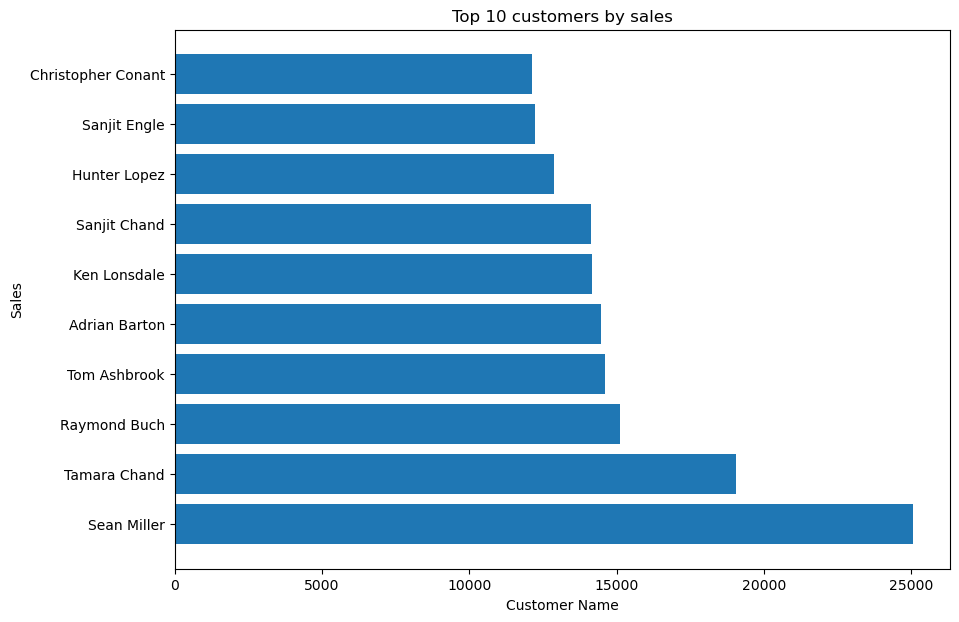

In [62]:
plt.figure(figsize=(10,7))
plt.barh(
    top_10_customers_by_sales['customer_name'],
    top_10_customers_by_sales['sales']
)
plt.title('Top 10 customers by sales')
plt.xlabel('Customer Name')
plt.ylabel('Sales')
plt.show()

In [63]:
top_10_customers_by_profit = df.groupby('customer_name',as_index=False)['profit'].sum().sort_values(by='profit',ascending=False).head(10)

In [64]:
print(top_10_customers_by_profit)

            customer_name     profit
730          Tamara Chand  8981.3239
622          Raymond Buch  6976.0959
671          Sanjit Chand  5757.4119
334          Hunter Lopez  5622.4292
6           Adrian Barton  5444.8055
757          Tom Ashbrook  4703.7883
157  Christopher Martinez  3899.8904
431         Keith Dawkins  3038.6254
35            Andy Reiter  2884.6208
194         Daniel Raglin  2869.0760


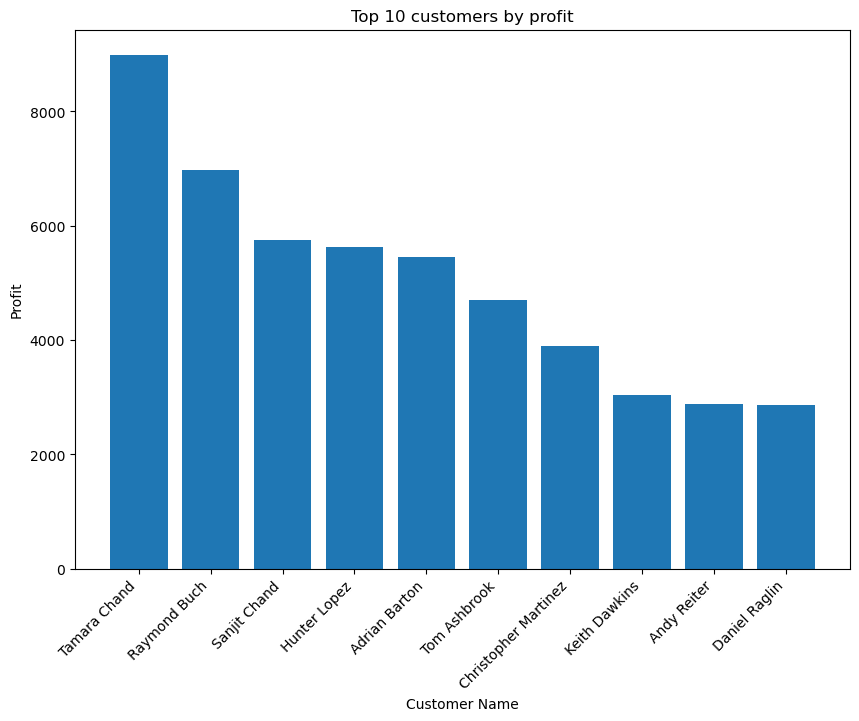

In [65]:
plt.figure(figsize=(10,7))
plt.bar(
    top_10_customers_by_profit['customer_name'],
    top_10_customers_by_profit['profit']
)
plt.title('Top 10 customers by profit')
plt.xlabel('Customer Name')
plt.ylabel('Profit')
plt.xticks(rotation=45,ha='right')
plt.show()


In [66]:
customers_sales = (df.groupby('customer_name',as_index=False)['sales'].sum().sort_values(by='sales',ascending=False))

In [67]:
customers_sales['cumulative_sales'] = customers_sales['sales'].cumsum()

In [68]:
total_sales = customers_sales['sales'].sum()

In [69]:
customers_sales['cumulative_sales_percentage'] = (customers_sales['cumulative_sales']/total_sales)*100

In [70]:
print(customers_sales['cumulative_sales_percentage'])

686      1.090155
730      1.919522
622      2.577598
757      3.212964
6        3.843016
          ...    
656     99.998111
545     99.998840
123     99.999559
455     99.999790
737    100.000000
Name: cumulative_sales_percentage, Length: 793, dtype: float64


In [71]:
top_customers = customers_sales[customers_sales['cumulative_sales_percentage']<= 80]

In [72]:
print(top_customers)

      customer_name       sales  cumulative_sales  cumulative_sales_percentage
686     Sean Miller  25043.0500      2.504305e+04                     1.090155
730    Tamara Chand  19052.2180      4.409527e+04                     1.919522
622    Raymond Buch  15117.3390      5.921261e+04                     2.577598
757    Tom Ashbrook  14595.6200      7.380823e+04                     3.212964
6     Adrian Barton  14473.5710      8.828180e+04                     3.843016
..              ...         ...               ...                          ...
344    Jamie Frazer   2279.5860      1.827758e+06                    79.564592
288     Fred Harton   2271.2840      1.830030e+06                    79.663464
176  Craig Carreira   2269.7015      1.832299e+06                    79.762267
93      Bobby Elias   2261.4380      1.834561e+06                    79.860710
413    Kalyca Meade   2260.9580      1.836822e+06                    79.959132

[395 rows x 4 columns]


### Analyse regional performance.

In [73]:
sales_by_region = df.groupby('region',as_index=False)['sales'].sum().sort_values(by='sales',ascending=False)

In [74]:
print(sales_by_region)

    region        sales
3     West  725457.8245
1     East  678781.2400
0  Central  501239.8908
2    South  391721.9050


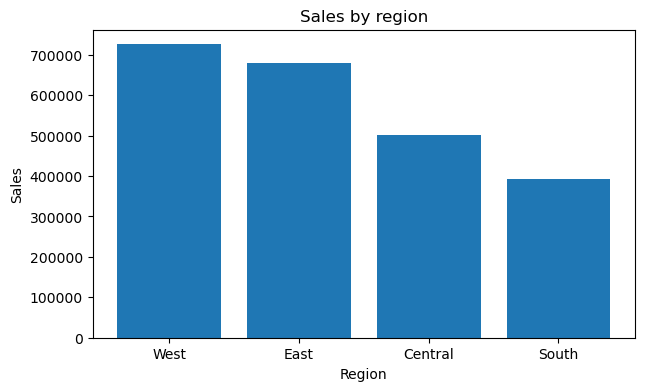

In [75]:
plt.figure(figsize=(7,4))
plt.bar(
    sales_by_region['region'],
    sales_by_region['sales']
)
plt.title('Sales by region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

In [76]:
profit_by_region = df.groupby('region',as_index=False)['profit'].sum().sort_values(by='profit',ascending=False)

In [77]:
print(profit_by_region)

    region       profit
3     West  108418.4489
1     East   91522.7800
2    South   46749.4303
0  Central   39706.3625


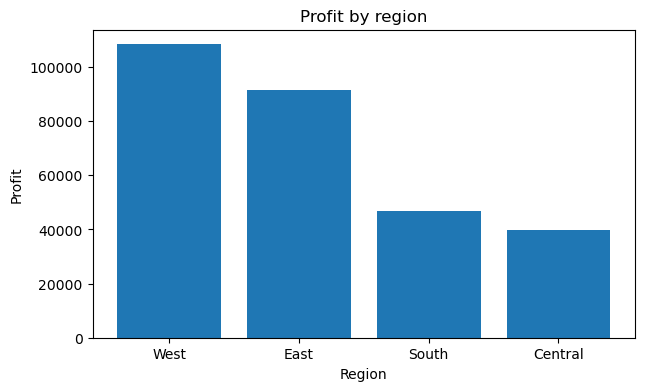

In [78]:
plt.figure(figsize=(7,4))
plt.bar(
    profit_by_region['region'],
    profit_by_region['profit']
)
plt.title('Profit by region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

In [80]:
profit_by_state = df.groupby('state',as_index=False)['profit'].sum().sort_values(by='profit',ascending=False)

In [81]:
Best_performing_state = profit_by_state.head()
Worst_performing_state = profit_by_state.tail()

In [82]:
print(Best_performing_state)

         state      profit
3   California  76381.3871
30    New York  74038.5486
45  Washington  33402.6517
20    Michigan  24463.1876
44    Virginia  18597.9504


In [83]:
print(Worst_performing_state)

             state      profit
31  North Carolina  -7490.9122
11        Illinois -12607.8870
36    Pennsylvania -15559.9603
33            Ohio -16971.3766
41           Texas -25729.3563


### Trend Analyis.

##### Analyse monthly sales trends :

In [84]:
monthly_sales = df.groupby('order_month_name',as_index=False)['sales'].sum().sort_values(by='sales',ascending=False)
best_monthly_sales = monthly_sales.head()
worst_monthly_sales = monthly_sales.tail()

In [85]:
print(best_monthly_sales)

   order_month_name        sales
9          November  352461.0710
2          December  325293.5035
11        September  307649.9457
7             March  205005.4888
10          October  200322.9847


In [86]:
print(worst_monthly_sales)

  order_month_name        sales
6             June  152718.6793
5             July  147238.0970
0            April  137762.1286
4          January   94924.8356
3         February   59751.2514


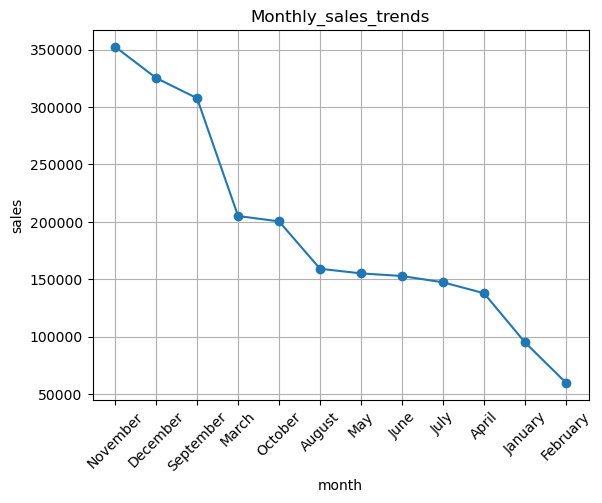

In [87]:
plt.plot( monthly_sales['order_month_name'],
         monthly_sales['sales'],
         marker = 'o'
        )
plt.title ('Monthly_sales_trends'),
plt.xlabel('month'),
plt.ylabel('sales'),
plt.xticks(rotation= 45)
plt.grid(True)
plt.show()
         

##### Analyse monthly profit trends:

In [88]:
monthly_profit = df.groupby('order_month_name',as_index=False)['profit'].sum().sort_values(by='order_month_name')

In [89]:
print(monthly_profit)

   order_month_name      profit
0             April  11587.4363
1            August  21776.9384
2          December  43369.1919
3          February  10294.6107
4           January   9134.4461
5              July  13832.6648
6              June  21285.7954
7             March  28594.6872
8               May  22411.3078
9          November  35468.4265
10          October  31784.0413
11        September  36857.4753


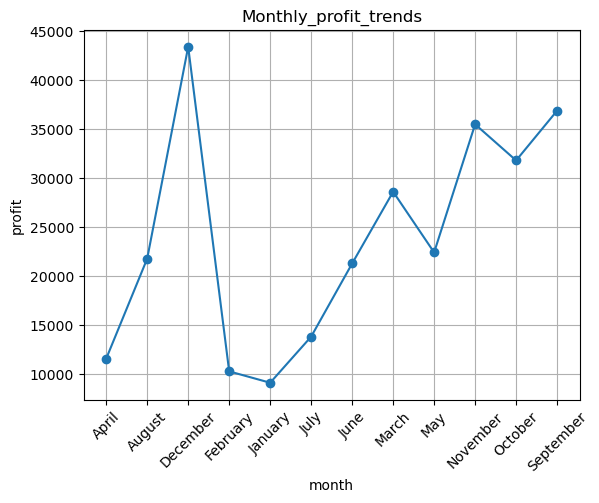

In [90]:
plt.plot(
    monthly_profit['order_month_name'],
    monthly_profit['profit'],
    marker = 'o'
)
plt.title('Monthly_profit_trends'),
plt.xlabel('month'),
plt.ylabel('profit'),
plt.xticks(rotation=45),
plt.grid(True)
plt.show()

In [91]:
print(monthly_profit.columns)

Index(['order_month_name', 'profit'], dtype='object')


##### Analyse shipping performance:

In [92]:
ship_mode_count = df.groupby('ship_mode',as_index=False).size().sort_values(by='size',ascending=False)

In [93]:
print(ship_mode_count)

        ship_mode  size
3  Standard Class  5968
2    Second Class  1945
0     First Class  1538
1        Same Day   543


In [94]:
highest_ship_mode = ship_mode_count.iloc[0]

In [95]:
print(highest_ship_mode)

ship_mode    Standard Class
size                   5968
Name: 3, dtype: object


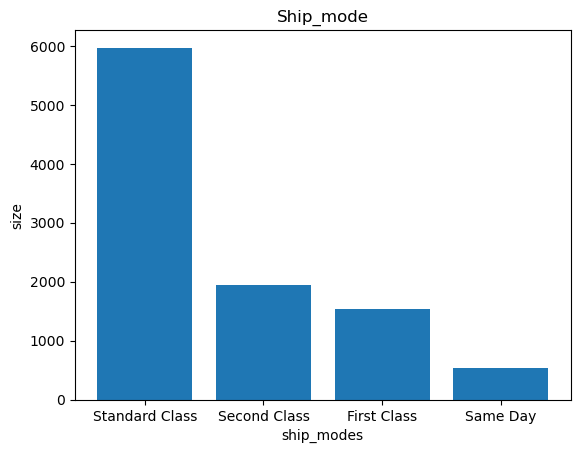

In [96]:
plt.bar(
    ship_mode_count['ship_mode'],
    ship_mode_count['size']
)
plt.title('Ship_mode'),
plt.xlabel('ship_modes'),
plt.ylabel('size'),
plt.show()

##### Analyse discount impact:

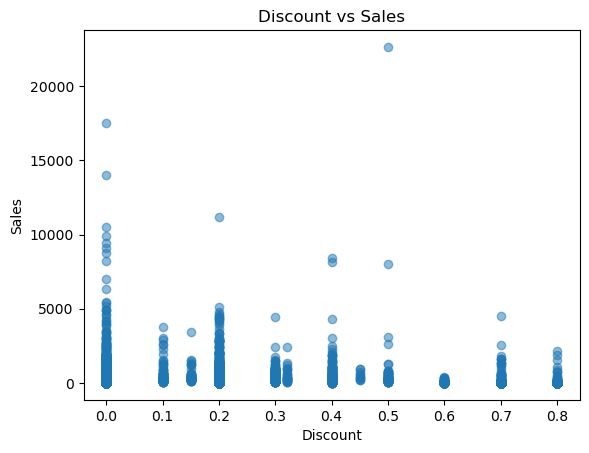

In [97]:
plt.scatter(
    df['discount'],
    df['sales'],
    alpha=0.5
)
plt.title('Discount vs Sales')
plt.xlabel('Discount')
plt.ylabel('Sales')
plt.show()

In [98]:
discount_sales_corr = df['discount'].corr(df['sales'])

In [99]:
print(discount_sales_corr)

-0.028190124157535475


In [100]:
average_sales_by_discount = df.groupby('discount',as_index=False)['sales'].mean().sort_values(by='discount')

In [101]:
print(average_sales_by_discount)

    discount       sales
0       0.00  226.742074
1       0.10  578.397351
2       0.15  529.971567
3       0.20  209.076940
4       0.30  454.742974
5       0.32  536.794770
6       0.40  565.134874
7       0.45  498.634000
8       0.50  892.705152
9       0.60   48.150000
10      0.70   97.177708
11      0.80   56.545853


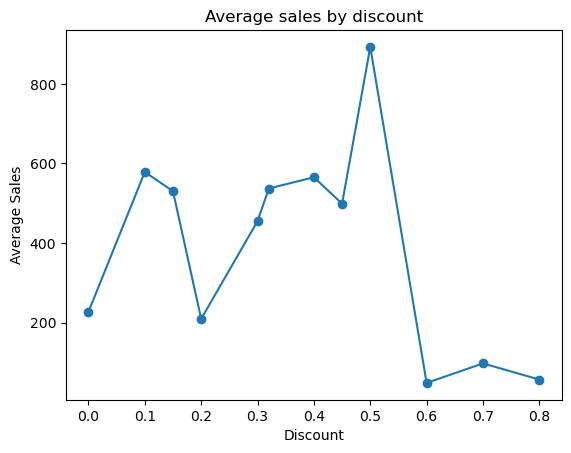

In [102]:
plt.plot(
    average_sales_by_discount['discount'],
    average_sales_by_discount['sales'],
    marker='o'
)
plt.title('Average sales by discount')
plt.xlabel('Discount')
plt.ylabel('Average Sales')
plt.show()

##### Perform correlation analysis :

In [103]:
correlation_data = df[['sales','profit','discount','quantity']]

In [104]:
correlation_matrix = correlation_data.corr()
print(correlation_matrix)

             sales    profit  discount  quantity
sales     1.000000  0.479064 -0.028190  0.200795
profit    0.479064  1.000000 -0.219487  0.066253
discount -0.028190 -0.219487  1.000000  0.008623
quantity  0.200795  0.066253  0.008623  1.000000


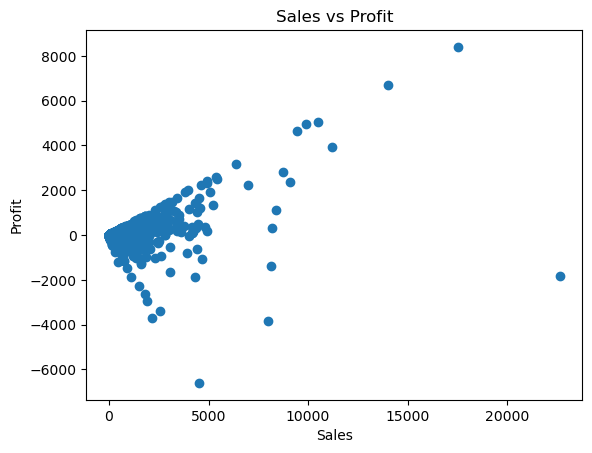

In [105]:
plt.scatter(
    df['sales'],
    df['profit']
    )
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

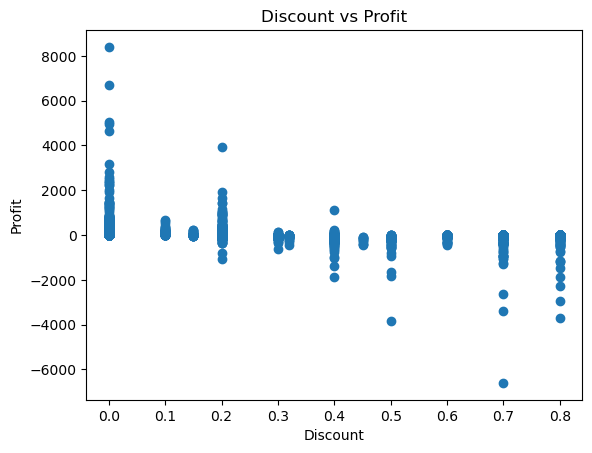

In [106]:
plt.scatter(
    df['discount'],
    df['profit']
)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

    

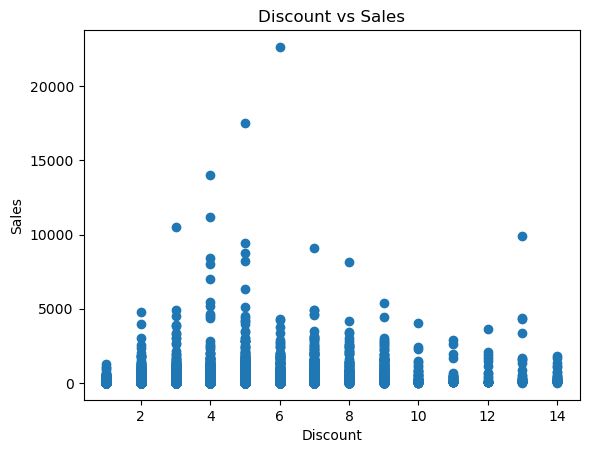

In [107]:
plt.scatter(
    df['quantity'],
    df['sales']
)
plt.title('Discount vs Sales')
plt.xlabel('Discount')
plt.ylabel('Sales')
plt.show()

### Business Insights :

#### Most profitable category :

#### Products consistently lose money:

#### Regions that need improvement :

#### Highest performing sales and profit months :

#### Higher Discounts Reduce Profitability :

### Recommend business actions :

#### Increase Sales - 

#### Improve Profit - 

#### Reduce Losses - 

#### Improve Customer Retention - 

### Conclusion